# Investigate initial-state constraint violations (beams-qss)

Rebuild the initial `CoilSupportBeamsSorted` state from `optimize_beams.py`
(without constructing `CoilFEMObjective` / cuDSS), then audit every constraint
the optimizer sees and resolve per-beam distances / angles along the chord.

In [1]:
from __future__ import annotations

from collections import defaultdict
from pathlib import Path
import json
import math

import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import Bounds, LinearConstraint

from simsopt.configs import get_data
from simsopt.mhd import Vmec
from simsopt.geo import CurveSurfaceDistance
from simsopt.field import Coil

from coil_fem.geo import make_framed_curve, CurveXYZFourierJAX
from coil_fem.meshing import FramedCurveMesh
from coil_fem.simsopt import (
    CoilSupportBeamsSorted,
    BeamSurfaceDistance,
    BeamCurveAngle,
    BeamCurveDistance,
)
from coil_fem.simsopt.objectives import _segment_point_dists

ROOT = Path('.').resolve()
assert (ROOT / 'optimize_beams.py').exists(), ROOT
OPTS_PATH = ROOT.parent / 'beam-options.json'
WOUT = ROOT.parent / 'fixed-continuation' / 'wout.nc'

       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



## 1. Rebuild the initial state (no FEM / no GPU)

In [2]:
eq = Vmec(str(WOUT), keep_all_files=True)
n_phi, n_theta = 25, 50
plasma_surface = type(eq.boundary)(
    nfp=eq.boundary.nfp,
    stellsym=eq.boundary.stellsym,
    mpol=eq.boundary.mpol,
    ntor=eq.boundary.ntor,
    quadpoints_phi=np.linspace(0, 1 / 2 / eq.boundary.nfp, n_phi, endpoint=False),
    quadpoints_theta=np.linspace(0, 1, n_theta, endpoint=False),
)
plasma_surface.set_dofs(eq.boundary.get_dofs())

w1_beam, w2_beam, t_beam = 0.2, 0.12, 0.03
fixed_dof_names = [
    'thetas_orientation_cc',
    'w1_beam',
    'w2_beam',
    't_beam',
]

coil_per_half_fp = 5
curves, currents, axis, nfp, bs = get_data(
    'w7x', coil_order=8, points_per_period=12,
)
base_curves = curves[:coil_per_half_fp]
base_currents = currents[:coil_per_half_fp]

opts = json.loads(OPTS_PATH.read_text())
mesh_options = opts['mesh_options']
beam_options = dict(opts['beam_options'])
beam_options['cross_section_type'] = 'hollow_rectangle'

base_coils = [Coil(c, I) for c, I in zip(base_curves, base_currents)]
coil_support = CoilSupportBeamsSorted(
    base_coils=base_coils,
    nfp=eq.boundary.nfp,
    stellsym=eq.boundary.stellsym,
    beam_options=beam_options,
    w1_beam=w1_beam,
    w2_beam=w2_beam,
    t_beam=t_beam,
    fixed_clamp_options={'enabled': False},
    fixed_dof_names=fixed_dof_names,
)

curves_jax = [CurveXYZFourierJAX.from_simsopt(c) for c in base_curves]
meshes = [
    FramedCurveMesh.from_options(
        make_framed_curve(c, mesh_options.get('frame', 'rmf')),
        mesh_options,
        mesh_options.get('mesh_type', 'TET10'),
    )
    for c in curves_jax
]
coil_support.support.bind_coil_meshes(meshes)

for c in base_curves:
    c.fix_all()
for cur in base_currents:
    cur.fix_all()

support = coil_support.support
print('n_beam_cc', support.n_beam_cc)
print('n_beam_cf', support.n_beam_cf)
print('n_beams_total', support.n_beams_total)
print('cc_groups', support.cc_groups)
print('# free dofs', len(coil_support.x))

k_attachment is not provided. Based on the coil's stiffness, the auto-generated value is 2.7956e+14 N/m3.


Beam network initialized.
Optimizing:
    dphis_end_cc - per-coil shapes: [(4,), (4,), (4,), (4,), (2,), (2,)]
    dphis_start_cc - per-coil shapes: [(4,), (4,), (4,), (4,), (2,), (2,)]
Fixing:
    thetas_orientation_cc
    w1_beam
    w2_beam
    t_beam
    dphis_start_cf
    x_foundation
    thetas_orientation_cf
Total # dofs: 40


n_beam_cc (4, 4, 4, 4, 2, 2)
n_beam_cf (0, 0, 0, 0, 0)
n_beams_total 20
cc_groups ((0, 1, 'none'), (1, 2, 'none'), (2, 3, 'none'), (3, 4, 'none'), (4, 4, 'flip_half'), (0, 0, 'flip'))
# free dofs 40


## 2. Confirm rebuild matches `init_Jstress.json`

In [3]:
saved = json.loads((ROOT / 'init_Jstress.json').read_text())
objs = saved['simsopt_objs']
cs_saved = objs['CoilSupportBeamsSorted1']
dofs_ref = cs_saved['dofs']['value']
dofs_obj = objs[dofs_ref]
x_saved = np.asarray(dofs_obj['x']['data'], dtype=float)
names_saved = list(dofs_obj['names'])
free_saved = np.asarray(dofs_obj['free']['data'], dtype=bool)
lb_saved = np.asarray(dofs_obj['lower_bounds']['data'], dtype=float)
ub_saved = np.asarray(dofs_obj['upper_bounds']['data'], dtype=float)

x_full = np.asarray(coil_support.local_full_x, dtype=float)
names_full = list(coil_support.local_full_dof_names)

# Align by name: simsopt may reorder free/fixed packing slightly across versions,
# but the full local DOF vector for CoilSupportBeamsSorted should match.
assert names_full == names_saved, (
    f'name mismatch: {set(names_full) ^ set(names_saved)}'
)
max_abs = float(np.max(np.abs(x_full - x_saved)))
print(f'max |x_rebuild - x_saved| = {max_abs:.3e}')
assert max_abs < 1e-12, max_abs

print('local_full_x matches init_Jstress.json')
print('# full local dofs', len(x_full), '# free', int(np.sum(free_saved)))
print('constructor kwargs also match:',
      cs_saved['w1_beam'], cs_saved['w2_beam'], cs_saved['t_beam'],
      cs_saved['fixed_dof_names'])
np.testing.assert_allclose(
    coil_support.local_full_lower_bounds, lb_saved, equal_nan=True)
np.testing.assert_allclose(
    coil_support.local_full_upper_bounds, ub_saved, equal_nan=True)
print('local full bounds also match')

max |x_rebuild - x_saved| = 0.000e+00
local_full_x matches init_Jstress.json
# full local dofs 120 # free 40
constructor kwargs also match: 0.2 0.12 0.03 ['thetas_orientation_cc', 'w1_beam', 'w2_beam', 't_beam']
local full bounds also match


## 3. Constraint audit

Active in `optimize_beams.py`:

1. box bounds from `Jstress.bounds` (unit interval on free `dphis_*`)
2. linear `sum_j dphis*[i][j] <= 1`
3. `constraint_from_optimizable(Jbsd, 0, 0)` (equality on a non-negative hinge)

`Jbca` / `Jbcd` are constructed but commented out of the constraint list — still evaluated here.

In [4]:
def _sum_dphis_constraint(dof_names):
    """Linear inequalities sum_j dphis*[i][j] <= 1 for each coil/group."""
    keys = ('dphis', 'dphis_start_cc', 'dphis_end_cc')
    groups = defaultdict(list)
    for j, name in enumerate(dof_names):
        local = name.split(':', 1)[-1]
        key = local.split('(', 1)[0]
        if key not in keys:
            continue
        i_coil = int(local.split('(', 1)[1].split(',', 1)[0])
        groups[(key, i_coil)].append(j)
    n = len(dof_names)
    if not groups:
        return LinearConstraint(np.zeros((0, n)), -np.inf, np.zeros(0)), []
    A = np.zeros((len(groups), n))
    labels = []
    for row, ((key, i_coil), idxs) in enumerate(groups.items()):
        A[row, idxs] = 1.0
        labels.append(f'{key}[{i_coil}]')
    return LinearConstraint(A, -np.inf, np.ones(A.shape[0])), labels


# Free DOFs are what trust-constr sees after coils/currents are fixed.
x = np.asarray(coil_support.x, dtype=float)
lb, ub = coil_support.bounds
lb = np.asarray(lb, dtype=float)
ub = np.asarray(ub, dtype=float)
dof_names = list(coil_support.dof_names)

bound_rows = []
for name, xi, lo, hi in zip(dof_names, x, lb, ub):
    below = lo - xi if xi < lo - 1e-14 else 0.0
    above = xi - hi if xi > hi + 1e-14 else 0.0
    if below > 0 or above > 0:
        bound_rows.append({
            'name': name,
            'x': xi,
            'lb': lo,
            'ub': hi,
            'violation_below': below,
            'violation_above': above,
        })
df_bounds = pd.DataFrame(bound_rows)
print(f'box-bound violations: {len(df_bounds)} / {len(x)} free dofs')
display(df_bounds if len(df_bounds) else pd.DataFrame(columns=['name', 'x', 'lb', 'ub']))

lin_con, lin_labels = _sum_dphis_constraint(dof_names)
Ax = lin_con.A @ x
df_lin = pd.DataFrame({
    'group': lin_labels,
    'sum_dphis': Ax,
    'ub': 1.0,
    'violation': np.maximum(Ax - 1.0, 0.0),
})
print('linear sum_dphis rows:')
display(df_lin)
print('linear violations:', int(np.sum(df_lin['violation'] > 1e-14)))

box-bound violations: 2 / 40 free dofs


,name,x,lb,ub,violation_below,violation_above
0,"CoilSupportBeamsSorted1:dphis_end_cc(4,1)",-0.25,0.0,1.0,0.25,0.0
1,"CoilSupportBeamsSorted1:dphis_end_cc(5,1)",-0.25,0.0,1.0,0.25,0.0


linear sum_dphis rows:


,group,sum_dphis,ub,violation
0,dphis_end_cc[0],0.875,1.0,0.0
1,dphis_end_cc[1],0.875,1.0,0.0
2,dphis_end_cc[2],0.875,1.0,0.0
3,dphis_end_cc[3],0.875,1.0,0.0
4,dphis_end_cc[4],0.625,1.0,0.0
5,dphis_end_cc[5],0.625,1.0,0.0
6,dphis_start_cc[0],0.875,1.0,0.0
7,dphis_start_cc[1],0.875,1.0,0.0
8,dphis_start_cc[2],0.875,1.0,0.0
9,dphis_start_cc[3],0.875,1.0,0.0


linear violations: 0


In [5]:
min_csd = float(CurveSurfaceDistance(base_curves, plasma_surface, 0).shortest_distance())
dmin_bsd = min_csd * 0.9
Jbsd = BeamSurfaceDistance(coil_support, plasma_surface, dmin_bsd)

Jbca = BeamCurveAngle(coil_support, minimum_angle=np.pi / 6, mode='all')

target_bcd = math.hypot(w1_beam, w2_beam) + math.hypot(mesh_options['w1'], mesh_options['w2'])
dead_length = target_bcd * 2
dmin_bcd = target_bcd * 0.8
Jbcd = BeamCurveDistance(
    coil_support,
    dead_length=dead_length,
    minimum_distance=dmin_bcd,
)

jbsd = float(Jbsd.J())
jbca = float(Jbca.J())
jbcd = float(Jbcd.J())
shortest_bsd = float(Jbsd.shortest_distance())
smallest_ang = float(Jbca.smallest_angle())
shortest_bcd = float(Jbcd.shortest_distance())

df_J = pd.DataFrame([
    {
        'objective': 'Jbsd',
        'J': jbsd,
        'diagnostic': shortest_bsd,
        'diagnostic_name': 'shortest_distance [m]',
        'threshold': dmin_bsd,
        'threshold_name': 'minimum_distance (=0.9*min_csd)',
        'min_csd': min_csd,
        'active_in_optimize': True,
        'constraint_form': 'equality J==0 (lb=ub=0)',
        'violates_zero': jbsd > 1e-14,
    },
    {
        'objective': 'Jbca',
        'J': jbca,
        'diagnostic': np.degrees(smallest_ang),
        'diagnostic_name': 'smallest_angle [deg]',
        'threshold': 30.0,
        'threshold_name': 'minimum_angle [deg]',
        'min_csd': np.nan,
        'active_in_optimize': False,
        'constraint_form': '(commented out)',
        'violates_zero': jbca > 1e-14,
    },
    {
        'objective': 'Jbcd',
        'J': jbcd,
        'diagnostic': shortest_bcd,
        'diagnostic_name': 'shortest_distance [m]',
        'threshold': dmin_bcd,
        'threshold_name': 'minimum_distance (=0.8*target_bcd)',
        'min_csd': np.nan,
        'active_in_optimize': False,
        'constraint_form': '(commented out)',
        'violates_zero': jbcd > 1e-14,
    },
])
print(f'target_bcd={target_bcd:.6f}  dead_length={dead_length:.6f}  dmin_bcd={dmin_bcd:.6f}')
print(f'min_csd={min_csd:.6f}  dmin_bsd={dmin_bsd:.6f}')
display(df_J)

target_bcd=0.516081  dead_length=1.032162  dmin_bcd=0.412865
min_csd=0.393934  dmin_bsd=0.354541


,objective,J,diagnostic,diagnostic_name,threshold,threshold_name,min_csd,active_in_optimize,constraint_form,violates_zero
0,Jbsd,0.0,0.407760,shortest_distance [m],0.354541,minimum_distance (=0.9*min_csd),0.393934,True,equality J==0 (lb=ub=0),False
1,Jbca,0.0,30.463825,smallest_angle [deg],30.000000,minimum_angle [deg],NaN,False,(commented out),False
2,Jbcd,0.0,inf,shortest_distance [m],0.412865,minimum_distance (=0.8*target_bcd),NaN,False,(commented out),False


## 4. Per-beam xi sweep (20 stations)

For each beam chord station `xi ∈ [0,1]`, report:

- beam–surface distance (min over plasma quadrature points)
- beam–start-curve distance
- beam–end-curve distance (end curve transformed for wrap groups)

Endpoints sit on the coil centreline, so `d_curve_start → 0` at `xi=0` and
`d_curve_end → 0` at `xi=1`. Shaded bands mark the dead-length / surface-exit
excluded regions used by `BeamCurveDistance`.

In [6]:
sdofs = coil_support.support_dofs
geom = support.beam_geometry(curves_jax, sdofs)
x_start = np.asarray(geom['x_start'])
x_end = np.asarray(geom['x_end'])
L = np.asarray(geom['L'])
xi_start = np.asarray(geom['xi_start'])
xi_end = np.asarray(geom['xi_end'])
L_eff = np.asarray(geom['L_eff'])
t_beam = np.asarray(geom['t_beam'])
t_coil_start = np.asarray(geom['t_coil_start'])
t_coil_end = np.asarray(geom['t_coil_end'])

n_beams = x_start.shape[0]
xi = np.linspace(0.0, 1.0, 20)
pts_xi = x_start[:, None, :] + xi[None, :, None] * (x_end - x_start)[:, None, :]  # (B, 20, 3)

gammas_surf = np.asarray(plasma_surface.gamma().reshape((-1, 3)))

# Map beam index -> (group, local_idx, start_coil, end_coil, transform)
beam_meta = []
b = 0
for g, (start_idx, end_idx, end_tfm) in enumerate(support.cc_groups):
    n_g = support.n_beam_cc[g]
    for j in range(n_g):
        beam_meta.append({
            'beam': b,
            'group': g,
            'local': j,
            'start_coil': start_idx,
            'end_coil': end_idx,
            'transform': end_tfm,
            'kind': 'cc',
        })
        b += 1
    # CF beams would sit between groups in coil-major order; n_beam_cf==0 here.
    if g < support.n_base:
        for j in range(support.n_beam_cf[g]):
            beam_meta.append({
                'beam': b,
                'group': g,
                'local': j,
                'start_coil': g,
                'end_coil': -1,
                'transform': 'none',
                'kind': 'cf',
            })
            b += 1
assert b == n_beams, (b, n_beams)

# Precompute per-group end-curve gammas (with wrap transform).
gamma_start_by_coil = {i: np.asarray(curves_jax[i].gamma()) for i in range(support.n_base)}
gamma_end_by_group = {}
for g, (start_idx, end_idx, end_tfm) in enumerate(support.cc_groups):
    ge = np.asarray(support._apply_end_transform(
        jnp.asarray(curves_jax[end_idx].gamma()), end_tfm,
    ))
    gamma_end_by_group[g] = ge

d_surface = np.zeros((n_beams, len(xi)))
d_curve_start = np.zeros((n_beams, len(xi)))
d_curve_end = np.zeros((n_beams, len(xi)))

for bi, meta in enumerate(beam_meta):
    for k in range(len(xi)):
        p = pts_xi[bi, k][None, :]  # (1, 3)
        # Degenerate segment = point-to-cloud distance via the shared helper.
        d_surface[bi, k] = float(jnp.min(_segment_point_dists(p, p, jnp.asarray(gammas_surf))))
        gs = gamma_start_by_coil[meta['start_coil']]
        d_curve_start[bi, k] = float(jnp.min(_segment_point_dists(p, p, jnp.asarray(gs))))
        if meta['kind'] == 'cc':
            ge = gamma_end_by_group[meta['group']]
            d_curve_end[bi, k] = float(jnp.min(_segment_point_dists(p, p, jnp.asarray(ge))))
        else:
            d_curve_end[bi, k] = np.nan

cols = [f'xi={v:.4f}' for v in xi]
idx = [f"b{m['beam']:02d}_g{m['group']}_c{m['start_coil']}->{m['end_coil']}_{m['transform']}"
       for m in beam_meta]
df_d_surf = pd.DataFrame(d_surface, index=idx, columns=cols)
df_d_start = pd.DataFrame(d_curve_start, index=idx, columns=cols)
df_d_end = pd.DataFrame(d_curve_end, index=idx, columns=cols)

print('d_surface [m]')
display(df_d_surf.round(4))
print('d_curve_start [m]')
display(df_d_start.round(4))
print('d_curve_end [m]')
display(df_d_end.round(4))

d_surface [m]


,xi=0.0000,xi=0.0526,xi=0.1053,xi=0.1579,xi=0.2105,xi=0.2632,xi=0.3158,xi=0.3684,xi=0.4211,xi=0.4737,xi=0.5263,xi=0.5789,xi=0.6316,xi=0.6842,xi=0.7368,xi=0.7895,xi=0.8421,xi=0.8947,xi=0.9474,xi=1.0000
b00_g0_c0->1_none,0.6484,0.6414,0.6379,0.6379,0.6333,0.6291,0.6284,0.6313,0.6275,0.6262,0.6284,0.6340,0.6321,0.6337,0.6388,0.6450,0.6459,0.6504,0.6582,0.6634
b01_g0_c0->1_none,0.5716,0.5724,0.5753,0.5756,0.5743,0.5752,0.5783,0.5777,0.5765,0.5774,0.5805,0.5817,0.5806,0.5818,0.5815,0.5787,0.5780,0.5796,0.5778,0.5754
b02_g0_c0->1_none,0.5066,0.5065,0.5066,0.5019,0.4980,0.4950,0.4928,0.4914,0.4910,0.4849,0.4796,0.4752,0.4713,0.4670,0.4636,0.4567,0.4483,0.4406,0.4338,0.4279
b03_g0_c0->1_none,0.6597,0.6590,0.6598,0.6624,0.6665,0.6672,0.6668,0.6681,0.6710,0.6755,0.6791,0.6795,0.6815,0.6851,0.6903,0.6968,0.6980,0.7006,0.7047,0.7103
b04_g1_c1->2_none,0.6634,0.6579,0.6560,0.6569,0.6511,0.6490,0.6506,0.6496,0.6473,0.6488,0.6540,0.6521,0.6535,0.6586,0.6632,0.6645,0.6694,0.6779,0.6802,0.6850
b05_g1_c1->2_none,0.5754,0.5778,0.5825,0.5816,0.5824,0.5854,0.5894,0.5885,0.5898,0.5930,0.5934,0.5929,0.5946,0.5986,0.5987,0.5990,0.6016,0.6055,0.6045,0.6058
b06_g1_c1->2_none,0.4279,0.4322,0.4324,0.4317,0.4318,0.4326,0.4342,0.4365,0.4365,0.4338,0.4314,0.4294,0.4280,0.4275,0.4276,0.4226,0.4178,0.4137,0.4103,0.4078
b07_g1_c1->2_none,0.7103,0.7115,0.7089,0.7075,0.7076,0.7090,0.7118,0.7119,0.7108,0.7110,0.7126,0.7155,0.7192,0.7183,0.7187,0.7204,0.7235,0.7279,0.7297,0.7302
b08_g2_c2->3_none,0.6850,0.6850,0.6839,0.6801,0.6793,0.6815,0.6787,0.6771,0.6785,0.6814,0.6790,0.6796,0.6832,0.6849,0.6848,0.6875,0.6932,0.6923,0.6944,0.6993
b09_g2_c2->3_none,0.6058,0.6104,0.6118,0.6131,0.6168,0.6199,0.6204,0.6233,0.6287,0.6286,0.6308,0.6355,0.6382,0.6398,0.6437,0.6488,0.6497,0.6531,0.6587,0.6600


d_curve_start [m]


,xi=0.0000,xi=0.0526,xi=0.1053,xi=0.1579,xi=0.2105,xi=0.2632,xi=0.3158,xi=0.3684,xi=0.4211,xi=0.4737,xi=0.5263,xi=0.5789,xi=0.6316,xi=0.6842,xi=0.7368,xi=0.7895,xi=0.8421,xi=0.8947,xi=0.9474,xi=1.0000
b00_g0_c0->1_none,0.0,0.0475,0.0949,0.1424,0.1859,0.2292,0.2739,0.3195,0.3655,0.4118,0.4584,0.5051,0.5519,0.5989,0.6455,0.6914,0.7375,0.7838,0.8302,0.8767
b01_g0_c0->1_none,0.0,0.0357,0.0714,0.0966,0.1212,0.1503,0.1818,0.2146,0.2482,0.2789,0.3090,0.3403,0.3723,0.4050,0.4381,0.4717,0.5055,0.5395,0.5738,0.6066
b02_g0_c0->1_none,0.0,0.0207,0.0413,0.0620,0.0826,0.1033,0.1239,0.1446,0.1653,0.1859,0.2066,0.2272,0.2479,0.2686,0.2892,0.3099,0.3305,0.3511,0.3711,0.3913
b03_g0_c0->1_none,0.0,0.0329,0.0659,0.0988,0.1294,0.1562,0.1850,0.2150,0.2457,0.2770,0.3086,0.3404,0.3725,0.4047,0.4359,0.4665,0.4974,0.5285,0.5599,0.5914
b04_g1_c1->2_none,0.0,0.0491,0.0983,0.1474,0.1966,0.2457,0.2949,0.3440,0.3932,0.4423,0.4915,0.5406,0.5898,0.6389,0.6880,0.7369,0.7857,0.8346,0.8835,0.9324
b05_g1_c1->2_none,0.0,0.0366,0.0732,0.1098,0.1464,0.1830,0.2196,0.2562,0.2928,0.3294,0.3660,0.4026,0.4392,0.4758,0.5124,0.5489,0.5855,0.6221,0.6587,0.6953
b06_g1_c1->2_none,0.0,0.0180,0.0360,0.0540,0.0720,0.0871,0.0969,0.1088,0.1222,0.1367,0.1519,0.1677,0.1839,0.2004,0.2171,0.2340,0.2483,0.2625,0.2772,0.2923
b07_g1_c1->2_none,0.0,0.0311,0.0622,0.0934,0.1245,0.1528,0.1795,0.2075,0.2362,0.2655,0.2951,0.3251,0.3552,0.3845,0.4127,0.4413,0.4703,0.4994,0.5288,0.5584
b08_g2_c2->3_none,0.0,0.0451,0.0901,0.1352,0.1802,0.2253,0.2704,0.3154,0.3596,0.4035,0.4476,0.4919,0.5363,0.5808,0.6254,0.6700,0.7147,0.7595,0.8043,0.8491
b09_g2_c2->3_none,0.0,0.0392,0.0784,0.1176,0.1567,0.1959,0.2351,0.2743,0.3135,0.3527,0.3919,0.4311,0.4702,0.5094,0.5486,0.5878,0.6270,0.6662,0.7054,0.7445


d_curve_end [m]


,xi=0.0000,xi=0.0526,xi=0.1053,xi=0.1579,xi=0.2105,xi=0.2632,xi=0.3158,xi=0.3684,xi=0.4211,xi=0.4737,xi=0.5263,xi=0.5789,xi=0.6316,xi=0.6842,xi=0.7368,xi=0.7895,xi=0.8421,xi=0.8947,xi=0.9474,xi=1.0000
b00_g0_c0->1_none,0.8974,0.8502,0.8030,0.7559,0.7088,0.6617,0.6147,0.5677,0.5209,0.4742,0.4272,0.3797,0.3322,0.2848,0.2373,0.1899,0.1424,0.0949,0.0475,0.0
b01_g0_c0->1_none,0.5997,0.5722,0.5457,0.5170,0.4887,0.4599,0.4296,0.4003,0.3679,0.3362,0.3054,0.2715,0.2378,0.2047,0.1726,0.1422,0.1071,0.0714,0.0357,0.0
b02_g0_c0->1_none,0.3787,0.3586,0.3386,0.3186,0.2988,0.2791,0.2595,0.2401,0.2210,0.2021,0.1836,0.1653,0.1446,0.1239,0.1033,0.0826,0.0620,0.0413,0.0207,0.0
b03_g0_c0->1_none,0.6139,0.5814,0.5488,0.5164,0.4840,0.4516,0.4194,0.3872,0.3552,0.3235,0.2919,0.2607,0.2300,0.1976,0.1647,0.1317,0.0988,0.0659,0.0329,0.0
b04_g1_c1->2_none,0.9231,0.8749,0.8267,0.7781,0.7293,0.6805,0.6318,0.5831,0.5346,0.4862,0.4379,0.3898,0.3421,0.2948,0.2457,0.1966,0.1474,0.0983,0.0491,0.0
b05_g1_c1->2_none,0.6851,0.6497,0.6135,0.5773,0.5412,0.5051,0.4691,0.4332,0.3974,0.3618,0.3264,0.2914,0.2562,0.2196,0.1830,0.1464,0.1098,0.0732,0.0366,0.0
b06_g1_c1->2_none,0.2714,0.2561,0.2411,0.2265,0.2125,0.1991,0.1865,0.1747,0.1582,0.1421,0.1266,0.1117,0.0979,0.0857,0.0759,0.0693,0.0540,0.0360,0.0180,0.0
b07_g1_c1->2_none,0.5912,0.5601,0.5290,0.4979,0.4668,0.4356,0.4045,0.3734,0.3423,0.3112,0.2801,0.2489,0.2178,0.1867,0.1556,0.1245,0.0934,0.0622,0.0311,0.0
b08_g2_c2->3_none,0.8261,0.7820,0.7382,0.6944,0.6509,0.6075,0.5644,0.5217,0.4787,0.4344,0.3904,0.3466,0.3031,0.2602,0.2182,0.1777,0.1352,0.0901,0.0451,0.0
b09_g2_c2->3_none,0.7445,0.7054,0.6662,0.6270,0.5878,0.5486,0.5094,0.4702,0.4311,0.3919,0.3527,0.3135,0.2743,0.2351,0.1959,0.1567,0.1176,0.0784,0.0392,0.0


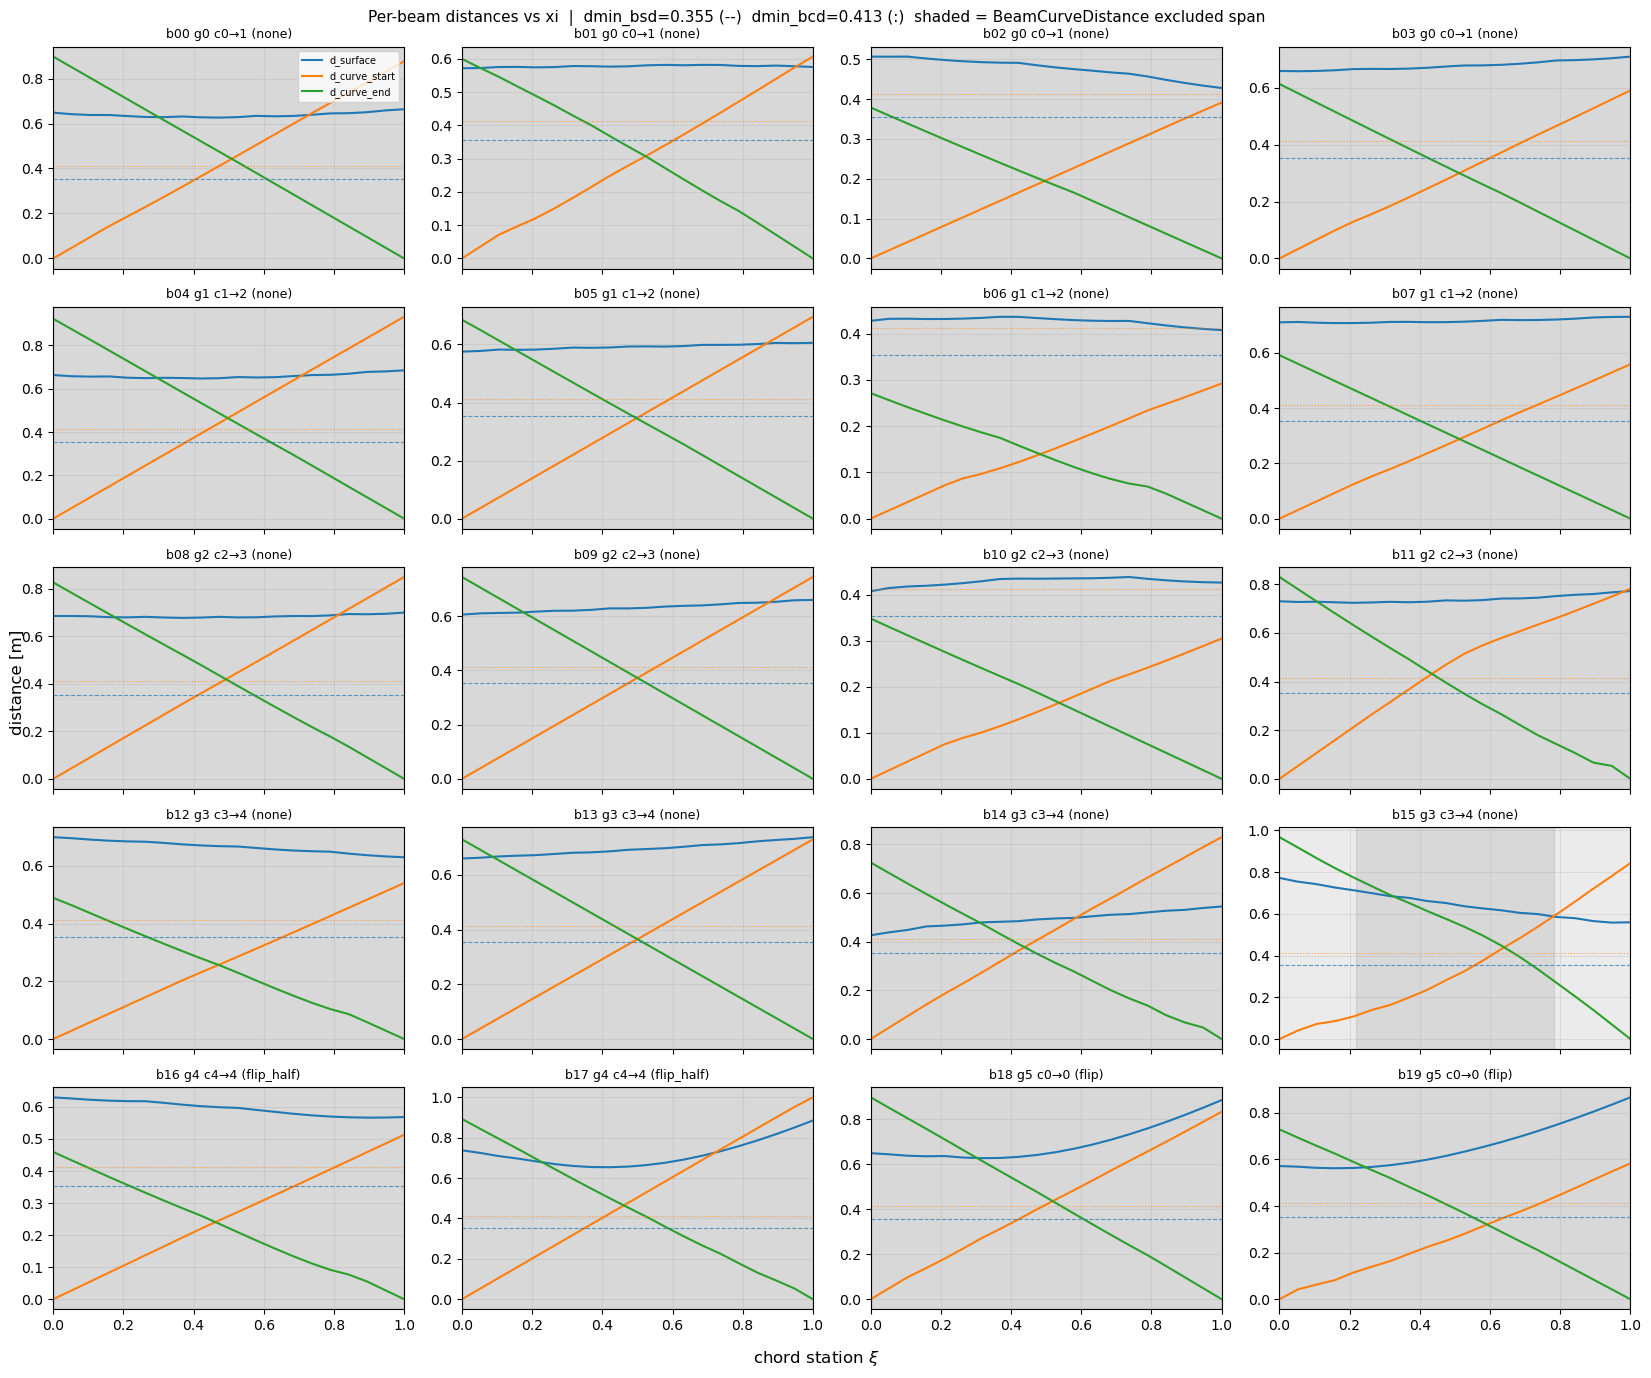

In [7]:
# Effective free-span stations used by BeamCurveDistance
xi_safe_start = dead_length / (L + 1e-300)
xi_safe_end = 1.0 - dead_length / (L + 1e-300)
xi_start_eff = np.maximum(xi_start, xi_safe_start)
xi_end_eff = np.minimum(xi_end, xi_safe_end)
active = xi_start_eff <= xi_end_eff

n_cols = 4
n_rows = int(math.ceil(n_beams / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 2.8 * n_rows), sharex=True)
axes = np.atleast_1d(axes).ravel()

for bi, meta in enumerate(beam_meta):
    ax = axes[bi]
    ax.plot(xi, d_surface[bi], 'C0-', label='d_surface')
    ax.plot(xi, d_curve_start[bi], 'C1-', label='d_curve_start')
    ax.plot(xi, d_curve_end[bi], 'C2-', label='d_curve_end')
    ax.axhline(dmin_bsd, color='C0', ls='--', lw=0.8, alpha=0.7)
    ax.axhline(dmin_bcd, color='C1', ls=':', lw=0.8, alpha=0.7)
    # Shade excluded ends: max(surface exit, dead length)
    ax.axvspan(0, xi_start_eff[bi], color='k', alpha=0.08)
    ax.axvspan(xi_end_eff[bi], 1, color='k', alpha=0.08)
    ax.set_title(
        f"b{bi:02d} g{meta['group']} "
        f"c{meta['start_coil']}→{meta['end_coil']} ({meta['transform']})",
        fontsize=9,
    )
    ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.3)

for ax in axes[n_beams:]:
    ax.axis('off')
axes[0].legend(fontsize=7, loc='upper right')
fig.supxlabel(r'chord station $\xi$')
fig.supylabel('distance [m]')
fig.suptitle(
    f'Per-beam distances vs xi  |  dmin_bsd={dmin_bsd:.3f} (--)  dmin_bcd={dmin_bcd:.3f} (:)  '
    f'shaded = BeamCurveDistance excluded span',
    fontsize=11,
)
fig.tight_layout()
plt.show()

## 5. Per-beam scalar table

In [8]:
cos_s = np.abs(np.sum(t_beam * t_coil_start, axis=-1))
cos_e = np.abs(np.sum(t_beam * t_coil_end, axis=-1))
ang_s_deg = np.degrees(np.arccos(np.clip(cos_s, 0.0, 1.0)))
ang_e_deg = np.degrees(np.arccos(np.clip(cos_e, 0.0, 1.0)))

rows = []
for bi, meta in enumerate(beam_meta):
    rows.append({
        'beam': bi,
        'group': meta['group'],
        'local': meta['local'],
        'start_coil': meta['start_coil'],
        'end_coil': meta['end_coil'],
        'transform': meta['transform'],
        'L': L[bi],
        'xi_start': xi_start[bi],
        'xi_end': xi_end[bi],
        'L_eff': L_eff[bi],
        'xi_safe_start': xi_safe_start[bi],
        'xi_safe_end': xi_safe_end[bi],
        'xi_start_eff': xi_start_eff[bi],
        'xi_end_eff': xi_end_eff[bi],
        'active_bcd': bool(active[bi]),
        'ang_start_deg': ang_s_deg[bi],
        'ang_end_deg': ang_e_deg[bi],
        'ang_start_ok': ang_s_deg[bi] >= 30.0 - 1e-9,
        'ang_end_ok': ang_e_deg[bi] >= 30.0 - 1e-9,
        'min_d_surface': float(np.min(d_surface[bi])),
        'min_d_surface_ok': float(np.min(d_surface[bi])) >= dmin_bsd - 1e-12,
        'min_d_curve_start_free': float(np.min(d_curve_start[bi, xi >= xi_start_eff[bi] - 1e-15]))
            if active[bi] else np.nan,
        'min_d_curve_end_free': float(np.min(d_curve_end[bi, xi <= xi_end_eff[bi] + 1e-15]))
            if active[bi] else np.nan,
    })

df_beams = pd.DataFrame(rows)
display(df_beams.round({
    'L': 4, 'xi_start': 4, 'xi_end': 4, 'L_eff': 4,
    'xi_safe_start': 4, 'xi_safe_end': 4,
    'xi_start_eff': 4, 'xi_end_eff': 4,
    'ang_start_deg': 2, 'ang_end_deg': 2,
    'min_d_surface': 4,
    'min_d_curve_start_free': 4, 'min_d_curve_end_free': 4,
}))

print('\nangle violations (< 30 deg):')
display(df_beams.loc[~(df_beams['ang_start_ok'] & df_beams['ang_end_ok']),
                     ['beam', 'group', 'transform', 'ang_start_deg', 'ang_end_deg']])
print('\nsurface-clearance violations (min_xi d_surface < dmin_bsd):')
display(df_beams.loc[~df_beams['min_d_surface_ok'],
                     ['beam', 'group', 'transform', 'min_d_surface']])
print('\ninactive BeamCurveDistance free spans:', int((~df_beams['active_bcd']).sum()))

,beam,group,local,start_coil,end_coil,transform,L,xi_start,xi_end,L_eff,...,xi_end_eff,active_bcd,ang_start_deg,ang_end_deg,ang_start_ok,ang_end_ok,min_d_surface,min_d_surface_ok,min_d_curve_start_free,min_d_curve_end_free
0,0,0,0,0,1,none,0.9018,0.1166,0.8849,0.6928,...,-0.1446,False,71.95,84.32,True,True,0.6262,True,NaN,NaN
1,1,0,1,0,1,none,0.6783,0.2078,0.8162,0.4127,...,-0.5217,False,55.43,74.78,True,True,0.5716,True,NaN,NaN
2,2,0,2,0,1,none,0.3925,0.2645,0.7178,0.1779,...,-1.6297,False,78.47,75.32,True,True,0.4279,True,NaN,NaN
3,3,0,3,0,1,none,0.6257,0.1739,0.8358,0.4141,...,-0.6497,False,67.07,76.84,True,True,0.6590,True,NaN,NaN
4,4,1,0,1,2,none,0.9338,0.1075,0.8846,0.7256,...,-0.1054,False,86.72,81.96,True,True,0.6473,True,NaN,NaN
5,5,1,1,1,2,none,0.6953,0.1855,0.8051,0.4308,...,-0.4844,False,86.66,81.09,True,True,0.5754,True,NaN,NaN
6,6,1,2,1,2,none,0.3418,0.3519,0.6139,0.0896,...,-2.0195,False,56.69,49.96,True,True,0.4078,True,NaN,NaN
7,7,1,3,1,2,none,0.5912,0.1797,0.8302,0.3846,...,-0.7458,False,72.74,88.41,True,True,0.7075,True,NaN,NaN
8,8,2,0,2,3,none,0.8561,0.1201,0.8734,0.6449,...,-0.2056,False,81.92,73.72,True,True,0.6771,True,NaN,NaN
9,9,2,1,2,3,none,0.7445,0.1850,0.8310,0.4809,...,-0.3863,False,88.38,88.81,True,True,0.6058,True,NaN,NaN



angle violations (< 30 deg):


,beam,group,transform,ang_start_deg,ang_end_deg



surface-clearance violations (min_xi d_surface < dmin_bsd):


,beam,group,transform,min_d_surface



inactive BeamCurveDistance free spans: 20


## 6. Findings

Executed with the `rod` kernel against the rebuilt initial state
(verified bitwise-identical to `init_Jstress.json`).


In [9]:
print('=== SUMMARY ===')
print(f'box-bound violations: {len(df_bounds)}')
if len(df_bounds):
    print(df_bounds.to_string(index=False))
print(f'linear sum_dphis violations: {int(np.sum(df_lin["violation"] > 1e-14))}')
print(f'Jbsd={jbsd:.6e}  shortest={shortest_bsd:.6f}  thresh={dmin_bsd:.6f}  '
      f'violates_eq0={jbsd > 1e-14}')
print(f'Jbca={jbca:.6e}  smallest_angle={np.degrees(smallest_ang):.3f} deg  '
      f'thresh=30 deg  violates_hinge0={jbca > 1e-14}')
print(f'Jbcd={jbcd:.6e}  shortest={shortest_bcd:.6f}  thresh={dmin_bcd:.6f}  '
      f'violates_hinge0={jbcd > 1e-14}')

# Wrap-group dphis diagnosis
print('\n=== wrap-group phis_end_cc / dphis_end_cc ===')
phis_end = [np.asarray(a) for a in sdofs['phis_end_cc']]
for g in range(len(phis_end)):
    pe = phis_end[g]
    dpe = np.diff(pe, prepend=0.0)
    print(f'  group {g}: phis_end={pe}  dphis_end={dpe}  '
          f'any_dphi_neg={bool(np.any(dpe < -1e-14))}')

=== SUMMARY ===
box-bound violations: 2
                                     name     x  lb  ub  violation_below  violation_above
CoilSupportBeamsSorted1:dphis_end_cc(4,1) -0.25 0.0 1.0             0.25              0.0
CoilSupportBeamsSorted1:dphis_end_cc(5,1) -0.25 0.0 1.0             0.25              0.0
linear sum_dphis violations: 0
Jbsd=0.000000e+00  shortest=0.407760  thresh=0.354541  violates_eq0=False
Jbca=0.000000e+00  smallest_angle=30.464 deg  thresh=30 deg  violates_hinge0=False
Jbcd=0.000000e+00  shortest=inf  thresh=0.412865  violates_hinge0=False

=== wrap-group phis_end_cc / dphis_end_cc ===
  group 0: phis_end=[0.125 0.375 0.625 0.875]  dphis_end=[0.125 0.25  0.25  0.25 ]  any_dphi_neg=False
  group 1: phis_end=[0.125 0.375 0.625 0.875]  dphis_end=[0.125 0.25  0.25  0.25 ]  any_dphi_neg=False
  group 2: phis_end=[0.125 0.375 0.625 0.875]  dphis_end=[0.125 0.25  0.25  0.25 ]  any_dphi_neg=False
  group 3: phis_end=[0.125 0.375 0.625 0.875]  dphis_end=[0.125 0.25  0.25

### Observations

1. **The only active-constraint violation at the initial point is the box bounds.**
   Two of 40 free DOFs sit below `lb = 0`:
   - `dphis_end_cc(4,1) = -0.25` (group 4, `flip_half`)
   - `dphis_end_cc(5,1) = -0.25` (group 5, `flip`)

   Cause: the two stellsym wrap groups default to a *decreasing*
   `phis_end_cc = [0.875, 0.625]`. The sorted parametrisation stores
   non-negative increments via `diff(..., prepend=0)`, so
   `dphis_end_cc = [0.875, -0.25]`. Linear `sum_dphis` rows are fine
   (all sums ≤ 0.875). This alone makes the start infeasible for
   `trust-constr`.

2. **`Jbsd = 0`** at init. Shortest beam–surface distance is 0.408 m vs
   threshold `0.9 * min_csd = 0.355` m. The equality constraint
   `constraint_from_optimizable(Jbsd, 0, 0)` is therefore satisfied, but
   the form is still ill-posed: wherever `J = 0` the Jacobian vanishes.
   Prefer `lb=-inf, ub=0`.

3. **`Jbca = 0`** (commented out of the constraint list). Smallest
   attachment angle is 30.46° vs the 30° floor — just feasible. Beam 15
   (group 3, local 3) is the tightest at the start end.

4. **`Jbcd = 0` trivially** (also commented out). With
   `dead_length = 2 * target_bcd ≈ 1.03` m, every beam's effective free
   span collapses (`xi_start_eff > xi_end_eff` for all 20 beams),
   so `shortest_distance()` returns `inf` and the hinge never activates.
   The per-beam xi plots still show the raw centreline distances: as
   expected, `d_curve_start → 0` at `ξ=0` and `d_curve_end → 0` at `ξ=1`.

5. **Surface clearance along the chord** is comfortable for every beam
   (`min_ξ d_surface ≥ 0.408 m > 0.355 m`). The constraint violation that
   blocks a feasible start is the wrap-group `dphis_end_cc` sign issue,
   not the nonlinear distance / angle hinges.
